# 04_04 Flow Direction (Gradient Vector Field)

## 1. Introduction

In the previous notebook we computed the magnitude of the terrain gradient, which we referred to as flow strength.

However, magnitude alone does not tell us where water moves.

To determine the direction of potential surface flow we must examine the full gradient vector.

The gradient vector points in the direction of maximum increase in elevation.

Because water flows downhill, surface runoff tends to move in the opposite direction of the gradient.

This notebook therefore introduces the concept of the terrain gradient as a vector field.

### Gradient Vector

The gradient of the elevation surface is:

$$
\nabla z =
\left(
\frac{\partial z}{\partial x},
\frac{\partial z}{\partial y}
\right)
$$

where:

- $\partial z/\partial x$ measures elevation change east-west
- $\partial z/\partial y$ measures elevation change north-south

These two components together form a vector.

### Flow Direction

Water moves in the direction of decreasing elevation.

Therefore:

$$
\vec{F} = -\nabla z
$$

The negative sign simply indicates that flow moves downhill rather than uphill.

The resulting vector field describes the direction that gravity-driven surface runoff would tend to follow if other forces are ignored.

### Practical Interpretation

Flow strength answered the question:

- "How rapidly does elevation change?"

Flow direction answers:

- "Which direction would water move?"

An analogy from basic calculus is useful.

For a one-dimensional function, the derivative gives the slope of a curve.

For a terrain surface, the gradient gives the slope in every direction simultaneously.

The flow vector then points downhill along the steepest path.

## 2. Imports

In [2]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

## 3. Load DEM Data

In [3]:
with rasterio.open("../../data/clipped_dem.tif") as src:
    dem = src.read(1)
    bounds = src.bounds
    nodata = src.nodata

dem = np.where(dem == nodata, np.nan, dem)

## 4. Compute Spatial Derivatives

The same spatial scaling used in the previous notebook is applied here.

This converts geographic coordinates into approximate horizontal distances measured in meters.

In [4]:
rows, cols = dem.shape

mean_lat = (bounds.top + bounds.bottom) / 2

lat_m = 111320
lon_m = 111320 * np.cos(np.radians(mean_lat))

dx_spacing = lon_m * (bounds.right - bounds.left) / cols
dy_spacing = lat_m * (bounds.top - bounds.bottom) / rows

dy, dx = np.gradient(
    dem,
    dy_spacing,
    dx_spacing
)

## 5. Compute Flow Vectors

The negative sign reverses the gradient.

The gradient points uphill.

Water flows downhill.

Therefore the flow field is the negative gradient.

In [5]:
flow_dx = -dx
flow_dy = -dy

## 6. Vector Magnitude

In [6]:
flow_strength = np.sqrt(
    flow_dx**2 +
    flow_dy**2
)

masked_flow = np.ma.masked_invalid(flow_strength)

## 7. Flow Direction Visualization

Because there are thousands of vectors in the DEM, the field is downsampled for visualization.

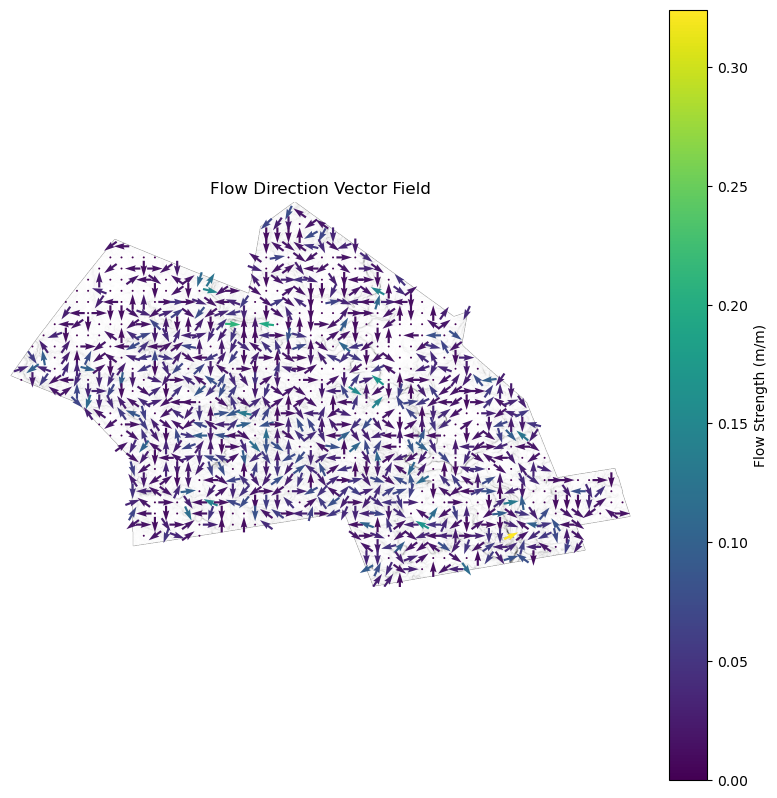

In [10]:
# downsample for readability
step = 32

x = np.arange(0, cols, step)
y = np.arange(0, rows, step)

X, Y = np.meshgrid(x, y)

U = flow_dx[::step, ::step]
V = -flow_dy[::step, ::step]

C = flow_strength[::step, ::step]

# unit vectors
mag = np.sqrt(U**2 + V**2)

U = np.divide(
    U,
    mag,
    out=np.zeros_like(U),
    where=mag > 0
)

V = np.divide(
    V,
    mag,
    out=np.zeros_like(V),
    where=mag > 0
)

plt.figure(figsize=(10, 10))

plt.imshow(
    masked_flow,
    cmap="Greys",
    alpha=1,
    origin="upper"
)

q = plt.quiver(
    X,
    Y,
    U,
    V,
    C,
    cmap="viridis",
    pivot="middle",
    scale=40,
    width=0.0035
)

plt.title("Flow Direction Vector Field")
plt.axis("off")

cbar = plt.colorbar(q)
cbar.set_label("Flow Strength (m/m)")

plt.show()

## 8. Interpretation

Each arrow represents the direction of maximum downhill descent.

Longer arrows indicate steeper terrain.

Shorter arrows indicate flatter terrain.

Areas where vectors converge often correspond to valleys, channels, and drainage pathways.

Areas where vectors diverge often correspond to ridges or elevated terrain.

## 9. Conclusion

Flow strength describes how rapidly elevation changes.

Flow direction describes where water would move.

Together, these two quantities form the basis of terrain-driven hydrological analysis.

If you revist the 3d Flow Strength visual from the last notebook you can see that when we normalize the flow strength there are many lit up peaks on top of the Waterloo Moraine which reveal a hidden flow layer, and make it look as though water is flowing down from the Moraine. However by looking at this flow vector chart we can see in many cases the arrows actually point inwards, or converge. Sometimes the may move in a circular pattern. All of this indicates that the water flow into the ground, and not down a hill. This all makes sense when you consider that  the Waterloo Moraine acts as a massive water filtration system that provides water to a large portion of Waterloo Region and surrounding wells. 

In the next notebook these flow directions will be used to route water downslope and compute flow accumulation, allowing drainage networks and stream channels to emerge from the terrain itself.